Kütüphanelerin import edilmesi

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

Verinin Yüklenmesi

In [93]:
df = pd.read_csv("wine.csv")
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


Verinin incelenmesi

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [95]:
df.describe()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


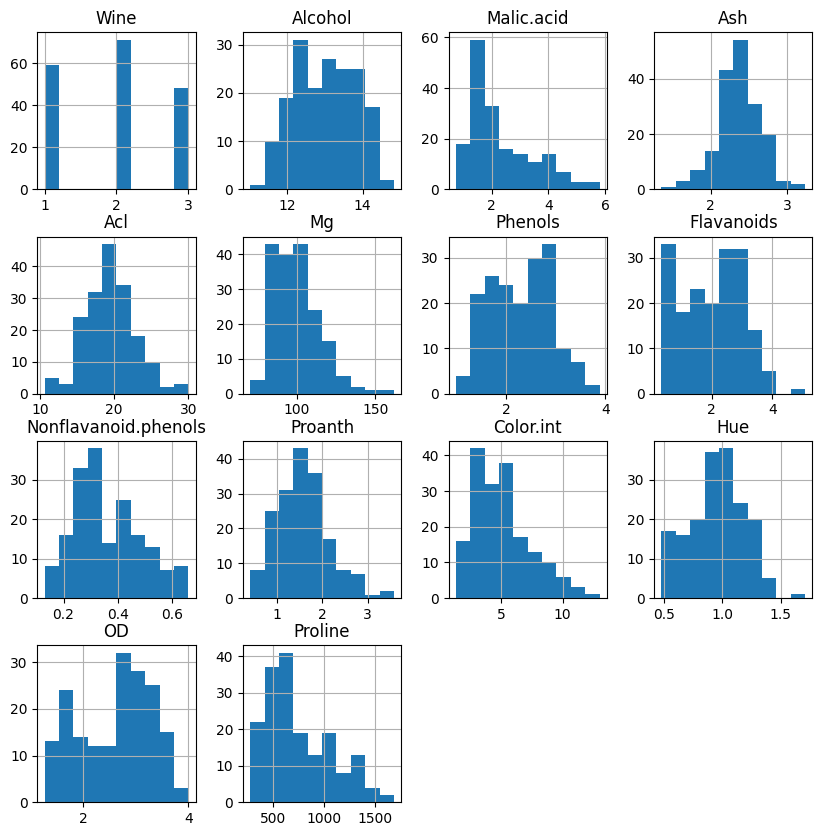

In [96]:
df.hist(figsize=(10,10));

In [97]:
# sns.pairplot(df,hue="Wine")

Verinin korelasyon matrisinin çıkarılması

<Axes: >

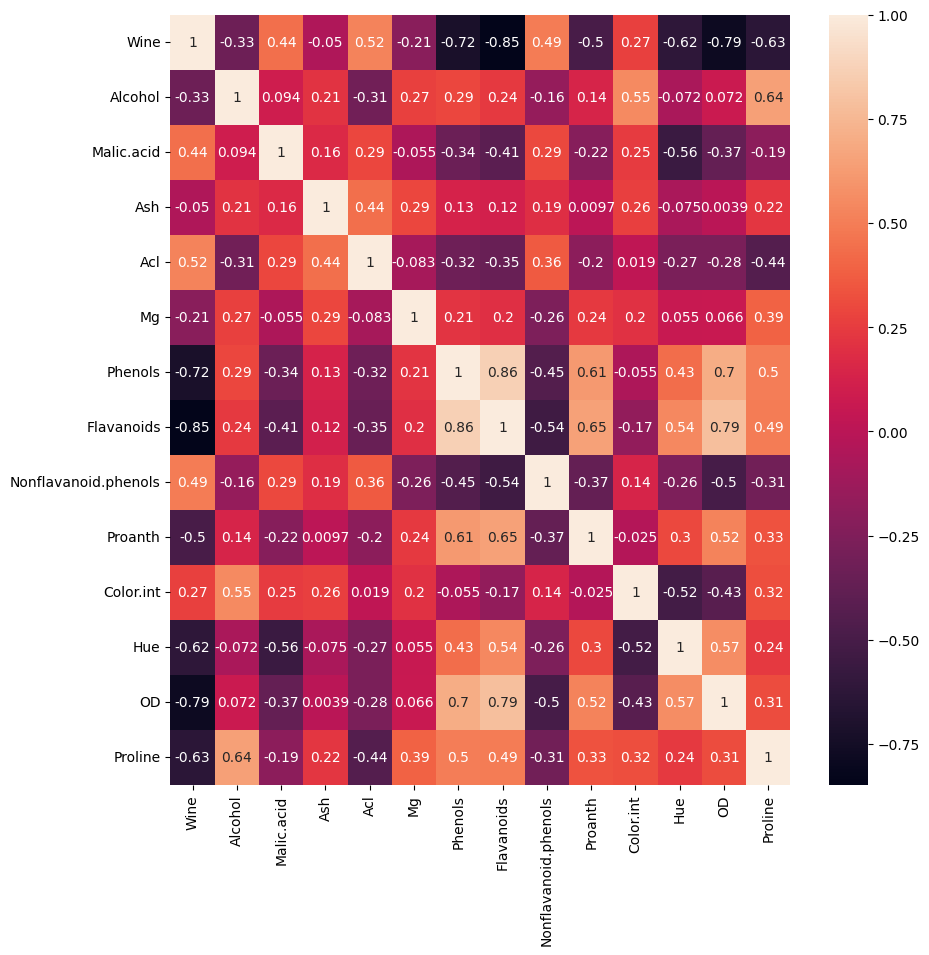

In [98]:
corr = df.corr()
fig = plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True)

Etiket ve özelliklerin birbirinden ayrılması

In [99]:
y = df["Wine"].values
X = df.drop("Wine",axis="columns").values

Eğitim ve Test verisinin oluşturulması

In [100]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=5)

ölçeklendirme

In [101]:
sc = StandardScaler()
sc.fit(X_train)
X_train_scaled = sc.transform(X_train)
X_test_scaled = sc.transform(X_test)

modellerin tanımlanması

In [102]:
models = [("LR",LogisticRegression()),("KNN",KNeighborsClassifier()),\
          ("SVC",SVC()),("RFC",RandomForestClassifier()),\
          ("DTC",DecisionTreeClassifier())]

In [103]:
isimler = []
sonuclar = []

## cross validation

In [104]:
from sklearn.model_selection import cross_val_score,KFold
fold = KFold(n_splits=5)
for isim,model in models:
  mod_res = cross_val_score(model,X_train_scaled,y_train,cv=fold,scoring="accuracy")
  sonuclar.append(mod_res)
  isimler.append(isim)
  print(f"{isim}  => {mod_res.mean()} => {mod_res.std()}")


LR  => 0.9859605911330049 => 0.01719910369467594
KNN  => 0.9514778325123153 => 0.0639047466311829
SVC  => 0.9862068965517242 => 0.01689303270884948
RFC  => 0.993103448275862 => 0.013793103448275846
DTC  => 0.9229064039408869 => 0.051710061420246936


En iyi modelin tespiti

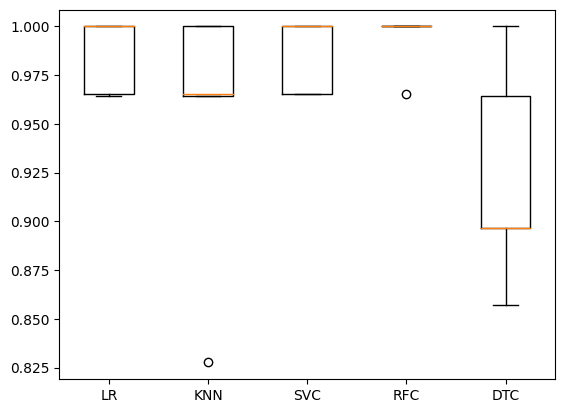

In [105]:
fig = plt.figure()
ax = fig.add_subplot(111)
plt.boxplot(sonuclar)
ax.set_xticklabels(isimler)
plt.show()

Hyper parametre tespiti

In [106]:
# test1 = SVC()
# test1.

In [107]:
svm = SVC()
param_grid = {'C': [0.1,1, 10, 100], 'gamma': [1,0.1,0.01,0.001],'kernel': ['rbf', 'poly', 'sigmoid']}

In [108]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

gridsearch = GridSearchCV(SVC(),cv=fold,param_grid=param_grid,scoring="accuracy",refit = True, verbose=2)


In [109]:
gridsearch.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, kernel=sigmoid; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, k

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'poly', 'sigmoid']},
             scoring='accuracy', verbose=2)

In [110]:
gridsearch.best_score_

0.9859605911330049

In [111]:
gridsearch.best_params_

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Modelin tüm veri ile eğitilmesi

In [112]:
model = SVC(C=10,gamma=0.01,kernel='rbf')

In [114]:
model.fit(X_train_scaled,y_train)

SVC(C=10, gamma=0.01)

In [116]:
y_preds = model.predict(X_test_scaled)

In [117]:
from sklearn.metrics import confusion_matrix,classification_report

In [118]:
conf = confusion_matrix(y_preds,y_test)

In [119]:
conf

array([[12,  1,  0],
       [ 0, 13,  0],
       [ 0,  0, 10]])

<Axes: >

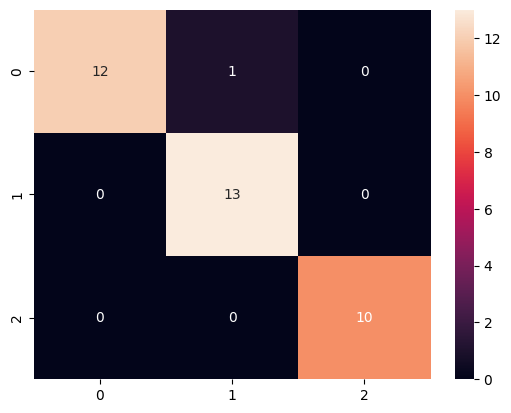

In [122]:
sns.heatmap(conf,annot=True)

In [123]:
print(classification_report(y_preds,y_test))

              precision    recall  f1-score   support

           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13
           3       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [125]:
olcekli_X = sc.transform(X)
modelSon = SVC(C=10,gamma=0.01,kernel='rbf')
modelSon.fit(olcekli_X,y)

SVC(C=10, gamma=0.01)

Modelin kaydedilmesi

In [126]:
import pickle
pickle.dump(modelSon,open("modelSon.pkl","wb"))
pickle.dump(sc,open("olcek.pkl","wb"))

In [128]:
data  = [[13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735]]

In [129]:
mod1 = pickle.load(open("modelSon.pkl","rb"))
olcek1 = pickle.load(open("olcek.pkl","rb"))

In [130]:
data_olcekli = olcek1.transform(data)

In [132]:
data_olcekli

array([[ 0.32606724,  0.16418317,  1.8070274 ,  0.45464584,  1.28766282,
         0.77982995,  0.64606182,  0.22967089,  0.35317441, -0.32458643,
         0.38723709,  0.41950474, -0.03271778]])

In [134]:
mod1.predict(data)

array([2])